# Προσομοιώσεις Πλεγμάτων Επιταχυντών με Python και Xsuite
# Μάθημα 2ο: Single particle dynamics in simple beamlines
#### Φυσική των Επιταχυντών
#### Μεταπτυχιακό Υποατομικής Φυσικής, 2o έτος
#### Τμήμα Φυσικής / Αριστοτέλειο Πανεπιστήμιο Θεσσαλονίκης
#### Εαρινό εξάμηνο 2025 

*T. Prebibaj, F. Antoniou, F. Asvesta, Y. Papaphilippou*

In [1]:
# Import custom tracking functions and useful libraries
from tracking_library import *
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

---
## 📌 FODO cell

### 🔹 Περιγραφή του FODO cell

<p align="center">
<img src=./images_lectures/fodo.png width="25%">
</p>

- Όπως είδατε στις διαλέξεις (*Μ2-δ25*), αυτό είναι ένα **κελί FODO**. Ένα κελί FODO είναι μία από τις πιο θεμελιώδεις τοπολογίες στα πλέγματα των επιταχυντών. Στην απλούστερη εκδοχή του, αποτελείται από δύο λεπτούς τετραπολικούς μαγνήτες με αντίθετα εστιακά μήκη, *f*, οι οποίοι απέχουν μεταξύ τους μέσω δύο ευθύγραμμων διαστημάτων μήκους *L* (το συνολικό μήκος του κελιού είναι 2*L).

- Μπορούμε να ξεκινήσουμε το FODO από οποιοδήποτε αυθαίρετο σημείο μέσα σε αυτό. Η γραμμή δέσμης που ορίσαμε στην Άσκηση 5 ήταν στην πραγματικότητα ένα κελί FODO που ξεκινούσε από το κέντρο του εστιακού τετραπόλου (όπως και στις διαλέξεις). Επομένως, εκείνο το κελί FODO αποτελούνταν από δύο "μισούς" εστιακούς τετραπολικούς (δηλαδή με το εστιακό μήκος διπλασιασμένο), έναν αποεστιακό τετραπολικό και δύο ευθύγραμμα διαστήματα.

### 📝 Άσκηση 6: tracking in a FODO cell

Ορίστε μια **γραμμή δέσμης τύπου FODO** που **ξεκινά από το μέσο ενός ευθύγραμμου διαστήματος** (drift).  
Στη συνέχεια, μοντελοποιήστε ένα σωματίδιο που βρίσκεται πάνω στον οπτικό άξονα ($x = 0$), αλλά έχει αρχική γωνία $x' = 1$ mrad, και σχεδιάστε τη θέση $x$ κατά μήκος της γραμμής δέσμης.  
Προς το παρόν, μπορούμε να ορίσουμε αυθαίρετα τις παραμέτρους $f$ και $L$ — επιλέγουμε 4 m και 2 m αντίστοιχα.

**Συμβουλή:** Για να οπτικοποιηθεί καλύτερα η τροχιά του σωματιδίου, είναι χρήσιμο να χωρίζουμε τα ευθύγραμμα διαστήματα σε πολλά μικρότερα (π.χ. $10$ διαστήματα μήκους $L/10$ το καθένα).


In [2]:
# FODO has two drifts of length L. Since we start at the middle of the drift, we will have:
# a drift of L/2, then a focusing quad, then a drift of L, then a defocusing quad and finally a drift of L/2
f = 4
L = 2
FODO = 5*D(L/10)+Q(f)+10*D(L/(10))+Q(-f)+5*D(L/10)

Text(0, 0.5, 'x [mm]')

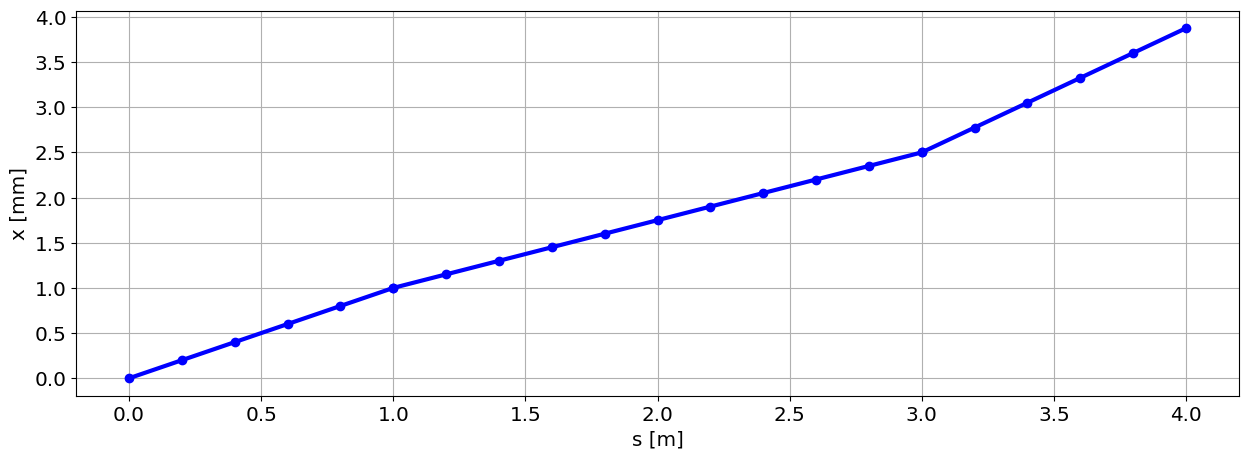

In [ ]:
# track and plot the particle trajectory
X = np.array([[0],
              [1e-3]])
transported_particles = transportParticles(X, FODO)
plt.plot(transported_particles['s'], transported_particles['x']*1e3, 'o-b', lw=3)
plt.grid(True)
plt.xlabel('s [m]')
plt.ylabel('x [mm]')

### 📝 Άσκηση 7: $x'$ του κελιού FODO  
Σχεδιάστε τη γωνία $x'$ κατά μήκος της γραμμής δέσμης.

Text(0, 0.5, "x' [mrad]")

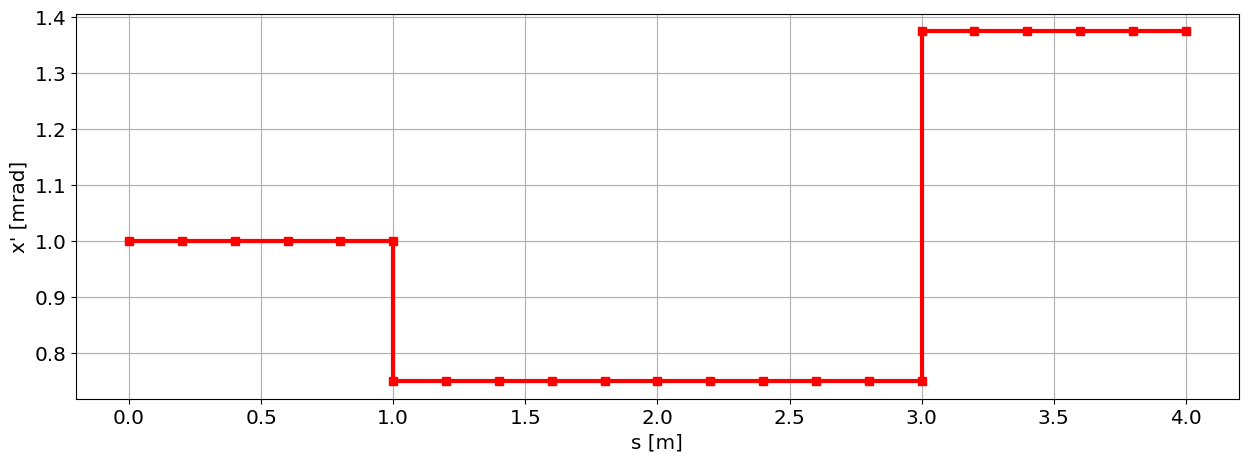

In [4]:
plt.plot(transported_particles['s'], transported_particles['xp']*1e3, 's-r', lw=3)
plt.grid(True)
plt.xlabel('s [m]')
plt.ylabel("x' [mrad]")

> Σημείωση: παρατηρήστε τις "ασυνεχειες" στην γωνία όταν το σωματίδιο εισέρχεται στο τετράπλο (αυτό είναι αποτέλεσμα της προσέγγισης του λεπτού φακού, στην πραγματικότητα η κίνηση προφανώς είναι συνεχής).


### 📝 Άσκηση 8: πολλαπλά κελιά FODO  

Σχεδιάστε τη θέση $x$ και τη γωνία $x'$ μέσα από πέντε κελιά. Υποθέστε ότι $(x_0, x'_0) = (0, 1)$ (mm, mrad).

**Συμβουλή:** Αφού σχεδιάσετε την τροχιά του $x$ σε ένα γράφημα, μπορείτε να δημιουργήσετε έναν δεύτερο κάθετο άξονα που να μοιράζεται τον ίδιο οριζόντιο άξονα χρησιμοποιώντας `plt.twinx()`.


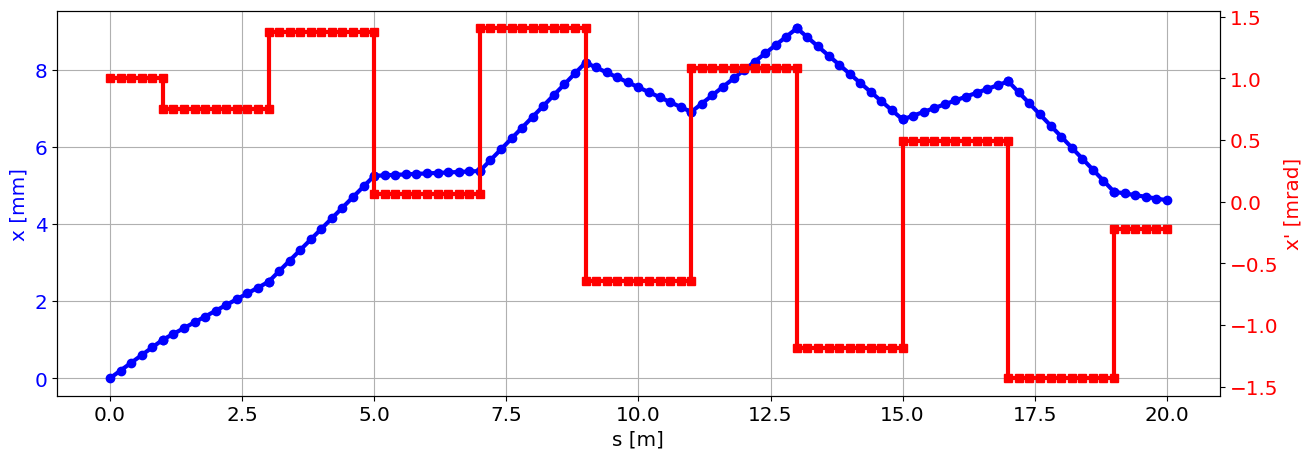

In [5]:
X = np.array([[0],
              [1e-3]])

# the transport over 5 cell can be achieved simply by multiplying the beamline description by 5
transported_particles = transportParticles(X, 5*FODO)
    
plt.plot(transported_particles['s'], transported_particles['x']*1e3, 'o-b', lw=3)
plt.grid(True)
plt.xlabel('s [m]')
plt.ylabel('x [mm]', color='b')
plt.tick_params(axis='y', labelcolor='b')

# instantiate a second axes that shares the same x-axis, and color it in red
plt.twinx()  
plt.ylabel("x' [mrad]", color='r')
plt.tick_params(axis='y', labelcolor='r')
# plot the angle as well:
plt.plot(transported_particles['s'], transported_particles['xp']*1e3, 's-r', lw=3)

### 📝 Άσκηση 9: βητατρονικές ταλαντώσεις  

Σχεδιάστε τη θέση $x$ και τη γωνία $x'$ μέσα από 100 κελιά.

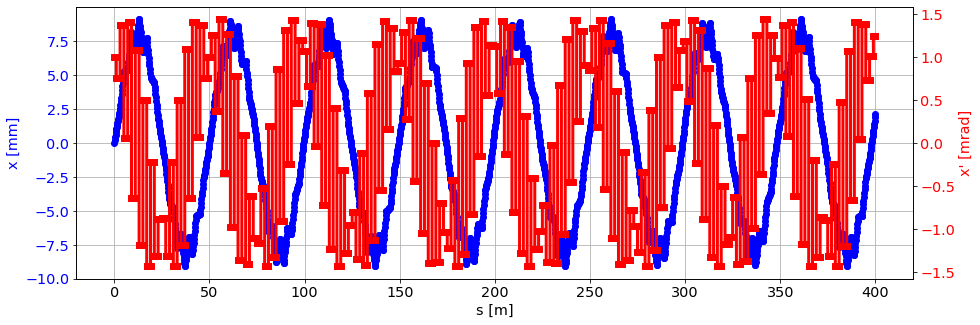

In [11]:
# code here your solution...

X = np.array([[0],
              [1e-3]])
transported_particles = transportParticles(X, 100*FODO)

plt.plot(transported_particles['s'], transported_particles['x']*1e3, 'o-b', lw=3)
plt.grid(True)
plt.xlabel('s [m]')
plt.ylabel('x [mm]', color='b')
plt.tick_params(axis='y', labelcolor='b')
ax2 = plt.twinx()
plt.ylabel("x' [mrad]", color='r')
plt.tick_params(axis='y', labelcolor='r')
plt.plot(transported_particles['s'], transported_particles['xp']*1e3, 's-r', lw=3)

> Σημείωση: το σωματίδιο πραγματοποιέι **ταλαντώσεις βήτατρον** (betatron oscillations).

### 📝 Άσκηση 10: σταθερότητα του κελιού FODO  

Πειραματιστείτε με διαφορετικές τιμές του εστιακού μήκους $f$ και δείτε αν μπορείτε να κάνετε τις ταλαντώσεις βήτατρον να αυξηθούν.


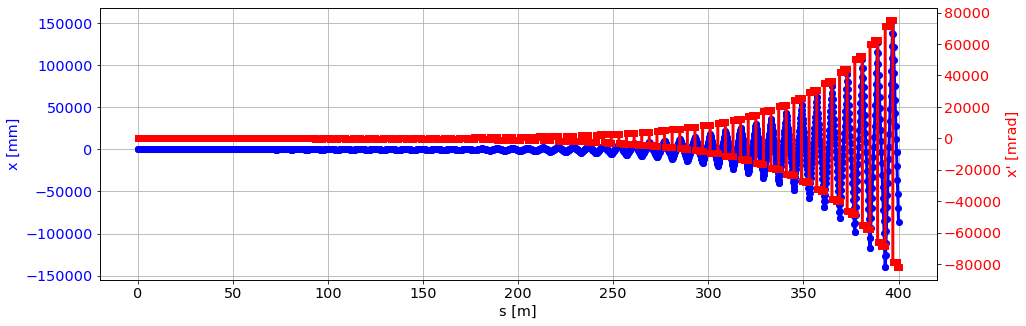

In [ ]:
# very strong focusing
f = 0.999
L = 2
FODO = 5*D(L/10)+Q(f)+10*D(L/(10))+Q(-f)+5*D(L/10)

X = np.array([[0],
              [1e-3]])
transported_particles = transportParticles(X, 100*FODO)

plt.plot(transported_particles['s'], transported_particles['x']*1e3, 'o-b', lw=3)
plt.grid(True)
plt.xlabel('s [m]')
plt.ylabel('x [mm]', color='b')
plt.tick_params(axis='y', labelcolor='b')
ax2 = plt.twinx()
plt.ylabel("x' [mrad]", color='r')
plt.tick_params(axis='y', labelcolor='r')
plt.plot(transported_particles['s'], transported_particles['xp']*1e3, 's-r', lw=3)

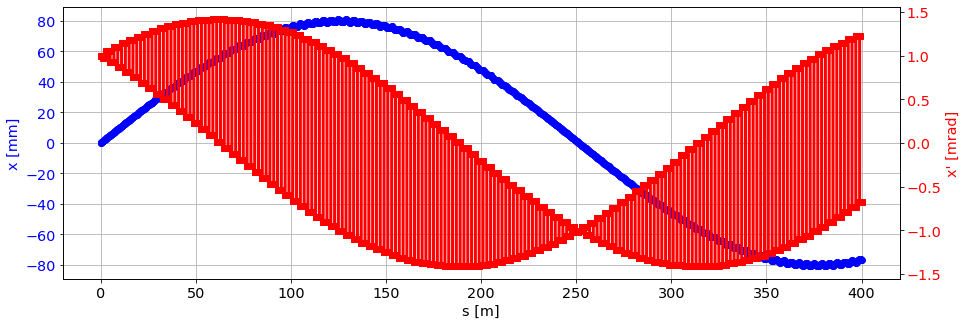

In [ ]:
# very weak focusing
f = 40
L = 2
FODO = 5*D(L/10)+Q(f)+10*D(L/(10))+Q(-f)+5*D(L/10)

X = np.array([[0],
              [1e-3]])
transported_particles = transportParticles(X, 100*FODO)

plt.plot(transported_particles['s'], transported_particles['x']*1e3, 'o-b', lw=3)
plt.grid(True)
plt.xlabel('s [m]')
plt.ylabel('x [mm]', color='b')
plt.tick_params(axis='y', labelcolor='b')
ax2 = plt.twinx()
plt.ylabel("x' [mrad]", color='r')
plt.tick_params(axis='y', labelcolor='r')
plt.plot(transported_particles['s'], transported_particles['xp']*1e3, 's-r', lw=3)

> Σημείωση: δεν δίνουν όλοι οι συνδυασμοί των $(f, L)$ μια σταθερή γραμμή δέσμης για τα σωματίδια. Θυμηθείτε το διάγραμμα σταθερότητας από το *M2-δ73*.
